In [3]:
# %%
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.layers import RepeatVector, TimeDistributed
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from tcn import TCN

# %%
df = pd.read_csv("/Users/anisa/OneDrive/Desktop/fyp/data/datab.csv", index_col=0)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["series_id", "date"])
df = df.set_index("date")
df = df.sort_index()

df.head(), len(df)


(                       geography                          stratum  \
 date                                                                
 2020-08-01       East of England                      Carbapenems   
 2020-08-01            North West                      Carbapenems   
 2020-08-01            North West                       Macrolides   
 2020-08-01  Yorkshire and Humber  Third Generation Cephalosporins   
 2020-08-01            South East                      Carbapenems   
 
                 organism  resistance_pct  \
 date                                       
 2020-08-01  P-aeruginosa            5.34   
 2020-08-01  K-pneumoniae            0.51   
 2020-08-01  S-pneumoniae           16.22   
 2020-08-01  K-pneumoniae           11.51   
 2020-08-01  K-pneumoniae            0.00   
 
                                                     series_id  \
 date                                                            
 2020-08-01         P-aeruginosa__Carbapenems__East of Engl

In [4]:
# %%
def add_features_per_series(df):
    dfs = []
    for sid, g in df.groupby("series_id"):
        g = g.sort_index()

        # seasonal
        g["month"] = g.index.month
        g["quarter"] = g.index.quarter
        g["year"] = g.index.year

        # target
        g["target"] = g["resistance_pct"]

        # lags
        g["lag_1"] = g["target"].shift(1)
        g["lag_3"] = g["target"].shift(3)
        g["lag_6"] = g["target"].shift(6)
        g["lag_12"] = g["target"].shift(12)

        # rolling
        g["roll_mean_3"] = g["target"].rolling(3).mean()
        g["roll_mean_6"] = g["target"].rolling(6).mean()
        g["roll_mean_12"] = g["target"].rolling(12).mean()
        g["roll_std_6"] = g["target"].rolling(6).std()

        dfs.append(g)

    out = pd.concat(dfs).sort_index()
    out = out.dropna()
    return out

df = add_features_per_series(df)

df = pd.get_dummies(
    df,
    columns=["geography", "stratum", "organism", "model_region"],
    drop_first=True
)

df = df.dropna()
df.shape


(13578, 44)

In [5]:
  # %%
train = df.loc[: "2023-12-01"]
test  = df.loc["2024-01-01":]

print(len(train), len(test))

X_train = train.drop(columns=["target", "resistance_pct", "series_id"])
y_train = train["target"]

X_test = test.drop(columns=["target", "resistance_pct", "series_id"])
y_test = test["target"]


8610 4968


In [6]:
# %%
feature_scaler = StandardScaler()
target_scaler  = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)
X_test_scaled  = feature_scaler.transform(X_test)

y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1,1)).flatten()
y_test_scaled  = target_scaler.transform(y_test.values.reshape(-1,1)).flatten()


In [17]:
# %%
def create_windows_multi(df, X_scaled, y_scaled, window, horizon):
    """
    Global windowing per series, with multi-step targets.
    For each series, we create:
      X: [t-window ... t-1]
      y: [t ... t+horizon-1]
    """
    Xs, ys = [], []
    start = 0

    for sid, g in df.groupby("series_id"):
        n = len(g)

        Xg = X_scaled[start:start+n]
        yg = y_scaled[start:start+n]

        for i in range(n - window - horizon + 1):
            Xs.append(Xg[i:i+window])
            ys.append(yg[i+window:i+window+horizon])

        start += n

    return np.array(Xs), np.array(ys)

window_length = 12
horizon = 6

X_train_seq, y_train_seq_multi = create_windows_multi(train, X_train_scaled, y_train_scaled, window_length, horizon)
X_test_seq,  y_test_seq_multi  = create_windows_multi(test,  X_test_scaled,  y_test_scaled,  window_length, horizon)

n_features = X_train_seq.shape[2]
X_train_seq.shape, y_train_seq_multi.shape


((5091, 12, 41), (5091, 6))

In [18]:
# All columns except target, resistance_pct, series_id
feature_cols = [
    col for col in df.columns
    if col not in ["target", "resistance_pct", "series_id"]
]


In [19]:
# %%
def invert_multi(pred):
    # pred: (samples, 6)
    inv = target_scaler.inverse_transform(pred)
    return inv

def evaluate_multi(y_true, y_pred):
    # y_true, y_pred: (samples, 6)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return mae, mape, mse, rmse

early_stop = EarlyStopping(patience=10, restore_best_weights=True)


In [20]:
# %%
def tcn_direct_model():
    model = Sequential()
    model.add(TCN(
        nb_filters=64,
        kernel_size=3,
        dilations=[1, 2, 4, 8],
        dropout_rate=0.2,
        input_shape=(window_length, n_features)
    ))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(horizon))  # 6 outputs
    model.compile(optimizer=Adam(0.001), loss="mse")
    return model

tcn_direct = tcn_direct_model()

history_tcn_direct = tcn_direct.fit(
    X_train_seq,
    y_train_seq_multi,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

y_pred_tcn_scaled = tcn_direct.predict(X_test_seq)
y_pred_tcn = invert_multi(y_pred_tcn_scaled)
y_true_tcn = invert_multi(y_test_seq_multi)

print("TCN Direct (6-step):", evaluate_multi(y_true_tcn, y_pred_tcn))


c:\Users\anisa\miniconda3\Lib\site-packages\tcn\tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


Epoch 1/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 2.5672 - val_loss: 1.1901
Epoch 2/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 1.0952 - val_loss: 1.1337
Epoch 3/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 1.0139 - val_loss: 1.1195
Epoch 4/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.9944 - val_loss: 1.1167
Epoch 5/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.9892 - val_loss: 1.1158
Epoch 6/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.9886 - val_loss: 1.1156
Epoch 7/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.9873 - val_loss: 1.1158
Epoch 8/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.9875 - val_loss: 1.1159
Epoch 9/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.9860 - val_loss: 1.1160
Epoch 10/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.9855 - val_loss: 1.1157
Epoch 11/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.9855 - val_loss: 1.1149
Epoch 12/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 

In [11]:
import numpy as np
from sklearn.metrics import mean_absolute_error

def per_horizon_mae(y_true, y_pred, model_name="Model"):
    print(f"\nPer‑horizon MAE for {model_name}:")
    for h in range(6):
        mae_h = mean_absolute_error(y_true[:, h], y_pred[:, h])
        print(f"Horizon {h+1}: MAE = {mae_h:.4f}")

# Example usage:
per_horizon_mae(y_true_tcn, y_pred_tcn, "TCN‑Direct")





Per‑horizon MAE for TCN‑Direct:
Horizon 1: MAE = 8.1384
Horizon 2: MAE = 8.0977
Horizon 3: MAE = 8.0447
Horizon 4: MAE = 8.0861
Horizon 5: MAE = 8.1843
Horizon 6: MAE = 8.1926


In [12]:
# Build a list of series_ids for each window in X_test_seq
series_ids_test = []

start = 0
for sid, g in test.groupby("series_id"):
    n = len(g)
    # number of windows for this series
    num_windows = n - window_length - 6 + 1
    if num_windows > 0:
        series_ids_test.extend([sid] * num_windows)

series_ids_test = np.array(series_ids_test)


In [13]:
def per_series_mae(y_true, y_pred, series_ids, model_name="Model"):
    print(f"\nPer‑series MAE for {model_name}:")
    results = []
    for sid in np.unique(series_ids):
        mask = series_ids == sid
        mae_sid = mean_absolute_error(y_true[mask].flatten(), y_pred[mask].flatten())
        results.append((sid, mae_sid))
        print(f"{sid}: MAE = {mae_sid:.4f}")
    return pd.DataFrame(results, columns=["series_id", "mae"])

# Example:
df_series_tcn = per_series_mae(y_true_tcn, y_pred_tcn, series_ids_test, "TCN‑Direct")


Per‑series MAE for TCN‑Direct:
E-coli__Amikacin__East Midlands: MAE = 5.8657
E-coli__Amikacin__East of England: MAE = 6.7116
E-coli__Amikacin__London: MAE = 18.1418
E-coli__Amikacin__North East: MAE = 6.8495
E-coli__Amikacin__North West: MAE = 12.6811
E-coli__Amikacin__South East: MAE = 8.4119
E-coli__Amikacin__South West: MAE = 10.9581
E-coli__Amikacin__West Midlands: MAE = 6.3799
E-coli__Amikacin__Yorkshire and Humber: MAE = 7.6228
E-coli__Carbapenems__East Midlands: MAE = 5.8231
E-coli__Carbapenems__East of England: MAE = 5.4299
E-coli__Carbapenems__London: MAE = 6.0002
E-coli__Carbapenems__North East: MAE = 5.3497
E-coli__Carbapenems__North West: MAE = 8.3416
E-coli__Carbapenems__South East: MAE = 9.8405
E-coli__Carbapenems__South West: MAE = 12.2232
E-coli__Carbapenems__West Midlands: MAE = 9.4393
E-coli__Carbapenems__Yorkshire and Humber: MAE = 8.8662
E-coli__Ciprofloxacin__East Midlands: MAE = 15.9238
E-coli__Ciprofloxacin__East of England: MAE = 8.4424
E-coli__Ciprofloxacin__L

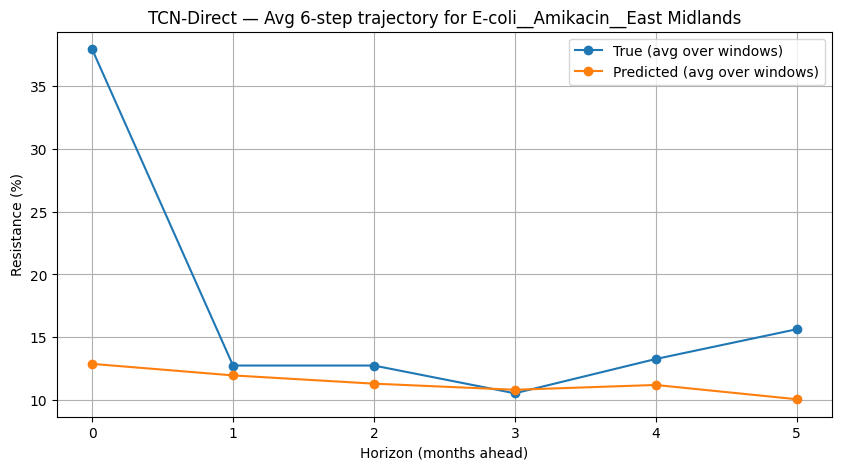

In [14]:
import matplotlib.pyplot as plt

def plot_series_trajectories(y_true, y_pred, series_ids, sid, model_name="Model"):
    mask = series_ids == sid
    yt = y_true[mask]
    yp = y_pred[mask]

    plt.figure(figsize=(10,5))
    plt.plot(yt.mean(axis=0), marker='o', label="True (avg over windows)")
    plt.plot(yp.mean(axis=0), marker='o', label="Predicted (avg over windows)")
    plt.title(f"{model_name} — Avg 6‑step trajectory for {sid}")
    plt.xlabel("Horizon (months ahead)")
    plt.ylabel("Resistance (%)")
    plt.legend()
    plt.grid(True)
    plt.show()

# Example:
example_sid = series_ids_test[0]
plot_series_trajectories(y_true_tcn, y_pred_tcn, series_ids_test, example_sid, "TCN‑Direct")


Backtesting/Cross validating TCN and LSTM

In [54]:
def rolling_backtest_dl_fast_per_series(
    df,
    feature_scaler,
    target_scaler,
    model_builder,
    feature_cols,
    window_length=6,
    horizon=6,
    min_history=12,
    step=6
):
    preds = []
    actuals = []
    dates = []
    series_ids_bt = []

    all_dates = sorted(df.index.unique())

    for i in range(min_history, len(all_dates) - horizon, step):

        train_end = all_dates[i]
        test_end  = all_dates[i + horizon]

        # GLOBAL TRAINING SET
        train = df.loc[:train_end]

        # Scale once per fold
        X_train = feature_scaler.fit_transform(train[feature_cols])
        y_train = target_scaler.fit_transform(train["target"].values.reshape(-1,1)).flatten()

        # Build windows once per fold
        X_train_seq, y_train_seq = create_windows_multi(
            train, X_train, y_train, window_length, horizon
        )

        if len(X_train_seq) == 0:
            continue

        # Train ONE model per fold
        model = model_builder()
        model.fit(X_train_seq, y_train_seq, epochs=1, batch_size=32, verbose=0)

        # Now predict for ALL series
        for sid, g in df.groupby("series_id"):

            g_test = g.loc[train_end:test_end]

            if len(g_test) >= window_length + horizon:

                X_test = feature_scaler.transform(g_test[feature_cols])
                y_test = target_scaler.transform(g_test["target"].values.reshape(-1,1)).flatten()

                X_last = X_test[-window_length:].reshape(1, window_length, -1)
                y_pred_s = model.predict(X_last)[0]
                y_pred = target_scaler.inverse_transform(y_pred_s.reshape(-1,1)).flatten()
                y_true = target_scaler.inverse_transform(y_test[-horizon:].reshape(-1,1)).flatten()

                preds.append(y_pred)
                actuals.append(y_true)
                dates.append(g_test.index[-horizon:])
                series_ids_bt.append(sid)

    return (
        np.array(preds),
        np.array(actuals),
        np.array(dates),
        np.array(series_ids_bt)
    )


In [55]:
results_dl = rolling_backtest_dl_fast_per_series(
    df,
    feature_scaler,
    target_scaler,
    tcn_direct_model,   # or lstm_direct_model, etc.
    feature_cols,
    window_length=6,
    horizon=6,
    min_history=12,
    step=6
)


c:\Users\anisa\miniconda3\Lib\site-packages\tcn\tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 586ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


c:\Users\anisa\miniconda3\Lib\site-packages\tcn\tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


c:\Users\anisa\miniconda3\Lib\site-packages\tcn\tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 553ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


c:\Users\anisa\miniconda3\Lib\site-packages\tcn\tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


c:\Users\anisa\miniconda3\Lib\site-packages\tcn\tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


In [56]:
y_pred_bt, y_true_bt, dates_bt, series_ids_bt = results_dl


In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_true_bt.flatten(), y_pred_bt.flatten())
rmse = np.sqrt(mean_squared_error(y_true_bt.flatten(), y_pred_bt.flatten()))

print("DL‑Direct Backtest MAE:", mae)
print("DL‑Direct Backtest RMSE:", rmse)


DL‑Direct Backtest MAE: 7.75409639891291
DL‑Direct Backtest RMSE: 10.199930170825922


In [59]:
np.unique(series_ids_bt)


array(['E-coli__Amikacin__South East', 'E-coli__Carbapenems__South East',
       'E-coli__Ciprofloxacin__South East',
       'E-coli__Co-amoxiclav__South East',
       'E-coli__Gentamicin__South East',
       'E-coli__Piperacillin with tazobactam__South East',
       'E-coli__Third Generation Cephalosporins__South East',
       'K-pneumoniae__Amikacin__South East',
       'K-pneumoniae__Carbapenems__South East',
       'K-pneumoniae__Ciprofloxacin__South East',
       'K-pneumoniae__Co-amoxiclav__South East',
       'K-pneumoniae__Gentamicin__South East',
       'K-pneumoniae__Piperacillin with tazobactam__South East',
       'K-pneumoniae__Third Generation Cephalosporins__South East',
       'P-aeruginosa__Amikacin__South East',
       'P-aeruginosa__Carbapenems__South East',
       'P-aeruginosa__Ceftazidime__South East',
       'P-aeruginosa__Ciprofloxacin__South East',
       'P-aeruginosa__Piperacillin with tazobactam__South East',
       'S-pneumoniae__Macrolides__South East',
  

In [60]:
def clean_predictions_dl(y_true, y_pred, dates, series_ids, series_id, horizon):
  
    # 1. Filter windows for this series
    mask = (series_ids == series_id)
    yt = y_true[mask]
    yp = y_pred[mask]
    dt = dates[mask]

    # 2. Extract the horizon column (0-indexed)
    h = horizon - 1
    actual = yt[:, h]
    pred   = yp[:, h]
    date   = dt[:, h]

    df = pd.DataFrame({
        "date": date,
        "actual": actual,
        "pred": pred
    })

    # 3. Deduplicate by keeping the most recent forecast origin
    df_clean = (
        df.sort_values("date")
          .drop_duplicates(subset="date", keep="last")
          .sort_values("date")
          .reset_index(drop=True)
    )

    return df_clean


In [61]:
print(np.unique(series_ids_bt))


['E-coli__Amikacin__South East' 'E-coli__Carbapenems__South East'
 'E-coli__Ciprofloxacin__South East' 'E-coli__Co-amoxiclav__South East'
 'E-coli__Gentamicin__South East'
 'E-coli__Piperacillin with tazobactam__South East'
 'E-coli__Third Generation Cephalosporins__South East'
 'K-pneumoniae__Amikacin__South East'
 'K-pneumoniae__Carbapenems__South East'
 'K-pneumoniae__Ciprofloxacin__South East'
 'K-pneumoniae__Co-amoxiclav__South East'
 'K-pneumoniae__Gentamicin__South East'
 'K-pneumoniae__Piperacillin with tazobactam__South East'
 'K-pneumoniae__Third Generation Cephalosporins__South East'
 'P-aeruginosa__Amikacin__South East'
 'P-aeruginosa__Carbapenems__South East'
 'P-aeruginosa__Ceftazidime__South East'
 'P-aeruginosa__Ciprofloxacin__South East'
 'P-aeruginosa__Piperacillin with tazobactam__South East'
 'S-pneumoniae__Macrolides__South East'
 'S-pneumoniae__Penicillin__South East'
 'e-faecalis__Glycopeptides__South East'
 'e-faecium__Glycopeptides__South East']


In [65]:
"K-pneumoniae__Third Generation Cephalosporins__Yorkshire and Humber" in series_ids_bt


False

In [66]:
sid = "K-pneumoniae__Third Generation Cephalosporins__Yorkshire and Humber"
df[df["series_id"] == sid].index.min(), df[df["series_id"] == sid].index.max()


(Timestamp('2021-08-01 00:00:00'), Timestamp('2025-06-01 00:00:00'))

In [67]:
df.loc["2023-12-01":"2024-06-01"].query("series_id == @sid")


,resistance_pct,series_id,prescribing_rate,month,quarter,year,target,lag_1,lag_3,lag_6,...,organism_P-aeruginosa,organism_S-pneumoniae,organism_e-faecalis,organism_e-faecium,model_region_London,model_region_Midlands,model_region_North East and Yorkshire,model_region_North West,model_region_South East,model_region_South West
date,,,,,,,,,,,,,,,,,,,,,
2023-12-01,17.77,K-pneumoniae__Third Generation Cephalosporins_...,1.74,12,4,2023,17.77,24.00,18.75,17.05,...,False,False,False,False,False,False,True,False,False,False
2024-01-01,13.93,K-pneumoniae__Third Generation Cephalosporins_...,1.74,1,1,2024,13.93,17.77,22.27,14.04,...,False,False,False,False,False,False,True,False,False,False
2024-02-01,11.82,K-pneumoniae__Third Generation Cephalosporins_...,1.74,2,1,2024,11.82,13.93,24.00,13.24,...,False,False,False,False,False,False,True,False,False,False
2024-03-01,12.26,K-pneumoniae__Third Generation Cephalosporins_...,1.73,3,1,2024,12.26,11.82,17.77,18.75,...,False,False,False,False,False,False,True,False,False,False
2024-04-01,14.21,K-pneumoniae__Third Generation Cephalosporins_...,1.75,4,2,2024,14.21,12.26,13.93,22.27,...,False,False,False,False,False,False,True,False,False,False
2024-05-01,16.34,K-pneumoniae__Third Generation Cephalosporins_...,1.75,5,2,2024,16.34,14.21,11.82,24.00,...,False,False,False,False,False,False,True,False,False,False
2024-06-01,17.39,K-pneumoniae__Third Generation Cephalosporins_...,1.74,6,2,2024,17.39,16.34,12.26,17.77,...,False,False,False,False,False,False,True,False,False,False


In [63]:
series_id_example = "K-pneumoniae__Third Generation Cephalosporins__Yorkshire and Humber"

clean_h6_dl = clean_predictions_dl(
    y_true_bt,
    y_pred_bt,
    dates_bt,
    series_ids_bt,
    series_id=series_id_example,
    horizon=6
)

clean_h6_dl.head()


,date,actual,pred


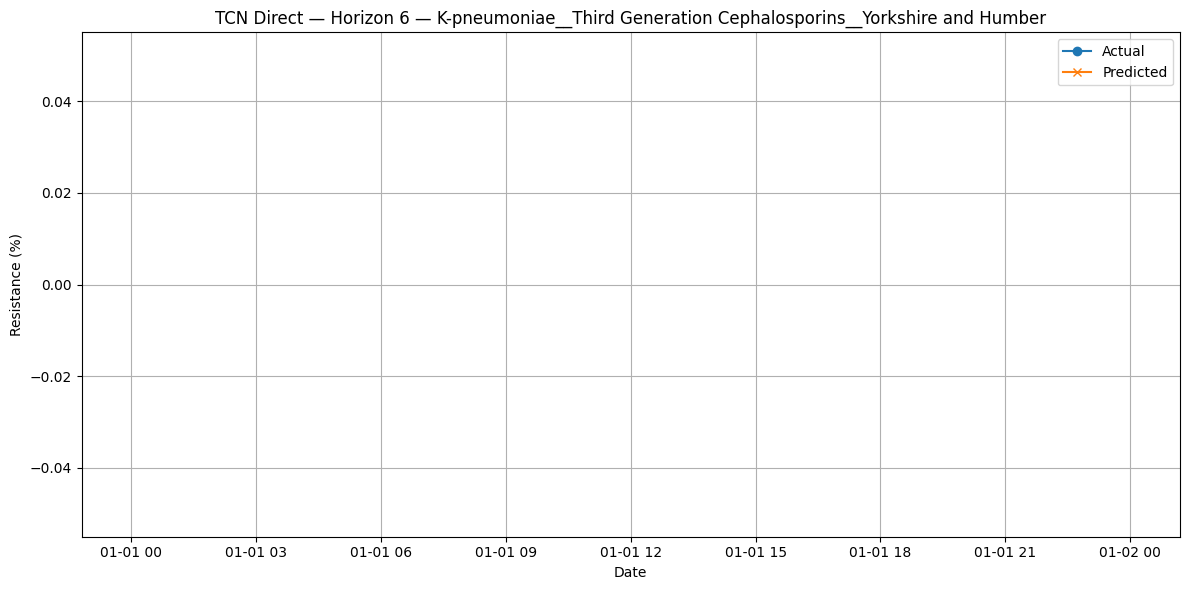

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(clean_h6_dl["date"], clean_h6_dl["actual"], marker="o", label="Actual")
plt.plot(clean_h6_dl["date"], clean_h6_dl["pred"], marker="x", label="Predicted")
plt.title(f"TCN Direct — Horizon 6 — {series_id_example}")
plt.xlabel("Date")
plt.ylabel("Resistance (%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
